In [46]:
%reload_ext autoreload
%autoreload 2
from analysis_stm import MotionAnalyzer,ExpMetaData, DiffusionPlotter
import numpy as np
from scipy.optimize import curve_fit
import trackpy as tp
from PIL import Image
import matplotlib.pyplot as plt
from sxmreader import SXMReader
import matplotlib as mpl
import scipy
from sxmreader import SXMReader
from PIL import Image
from matplotlib.ticker import MultipleLocator
from matplotlib.animation import FuncAnimation, PillowWriter
#%matplotlib widget
import ipywidgets as widgets
from scipy.optimize import minimize




In [47]:
import dill #loads
import os
ds=[]
for i in range(13):
    print(i)
    m=MotionAnalyzer()
    Folder='./Saved_trajectories/diffusion_paper/sd/'
    with open(Folder+sorted(os.listdir(Folder))[i], 'rb') as file:
        m.__dict__ = dill.load(file)
        file.close()

    ds.append(m)
for i in range(13):
    print(i)
    m=MotionAnalyzer()
    Folder='./Saved_trajectories/diffusion_paper/heater/'
    with open(Folder+sorted(os.listdir(Folder))[i], 'rb') as file:
        m.__dict__ = dill.load(file)
        file.close()

    ds.append(m)

0
1
2
3
4
5
6
7
8
9
10
11
12
0
1
2
3
4
5
6
7
8
9
10
11
12


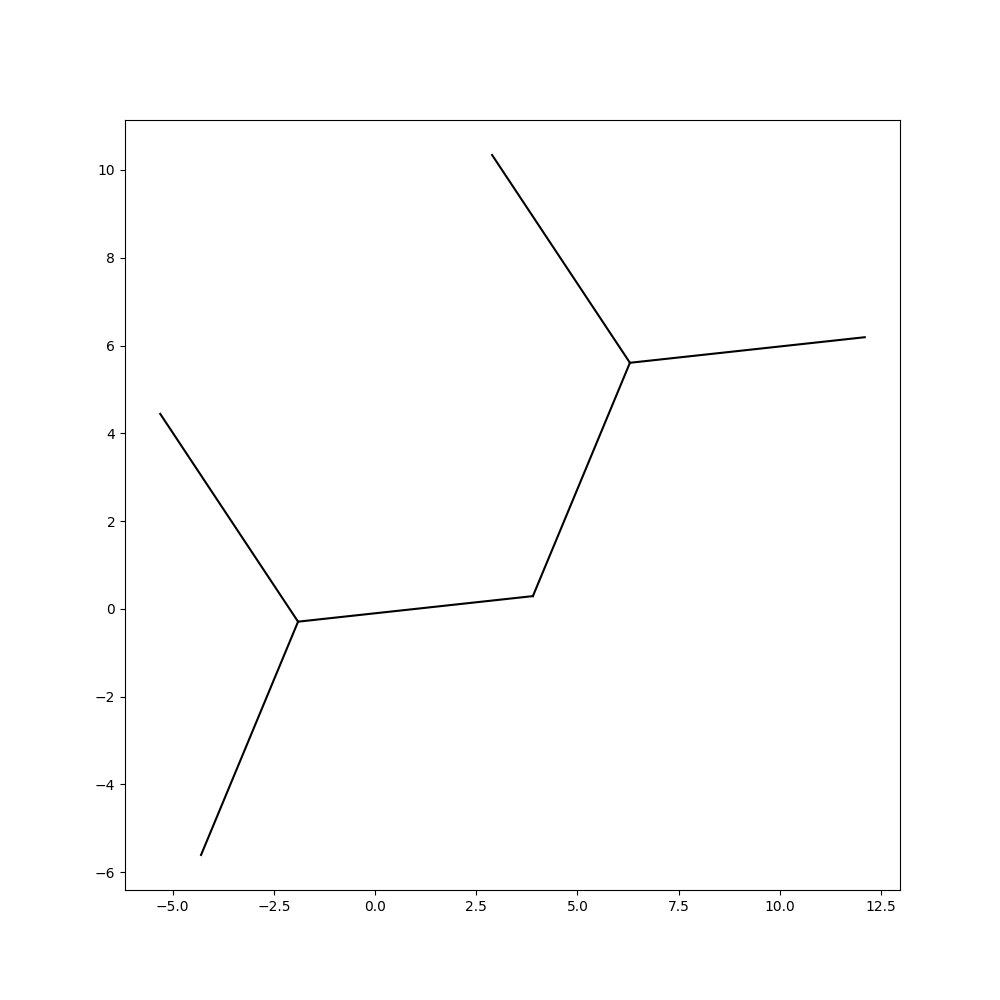

In [48]:
def add_lattice(ax,lattice,theta=0,point=(1,0),size=10,plotonly=True):
        s=lattice/np.sqrt(3)
        coord=np.arange(-size/2,size/2,lattice*np.sqrt(3))
        coord=coord-coord[int(np.size(coord)/2)]+point[0]-s/2
        coord2=np.arange(-size/2,size/2,lattice)
        coord2=coord2-coord2[int(np.size(coord2)/2)]+point[1]
        
        X,Y=np.meshgrid(coord,coord2)
        x,y=X.flatten(),Y.flatten()
        x2=x+lattice*np.sqrt(3)/2
        y2=y+lattice/2
        x=np.concatenate((x,x2))
        
        y=np.concatenate((y,y2))
        R = np.array([
            [np.cos(theta), -np.sin(theta)],
            [np.sin(theta), np.cos(theta)]])
        A=np.dot(R,np.vstack((x-point[0],y-point[1])))
        x=A[0]+point[0]
        y=A[1]+point[1]
        midx=[]
        midy=[]
        
        for i in range(np.size(x)):
            for j in range(3):
                dx=s*np.cos(theta+j*np.pi*2/3)
                dy=s*np.sin(theta+j*np.pi*2/3)
                if plotonly:
                    ax.plot([x[i],x[i]+dx],[y[i],y[i]+dy],color='black')
                midx.append((2*x[i]+dx)/2)
                midy.append((2*y[i]+dy)/2)
        if not plotonly:
            return(np.column_stack((midx,midy)))
def optimal_rotation(set1, set2, pivot,theta_0=0):
    def rotate_points(points, theta, pivot):
        R = np.array([
            [np.cos(theta), -np.sin(theta)],
            [np.sin(theta), np.cos(theta)]
        ])
        return np.dot(points - pivot, R.T) + pivot

    def cost_function(theta):
        rotated_set1 = rotate_points(set1, theta, pivot)
        distances = np.sqrt(np.sum((rotated_set1[:, None, :] - set2)**2, axis=2))
        return np.sum(np.min(distances, axis=1))
    initial_guess = theta_0
    result = minimize(cost_function, initial_guess, bounds=[(-np.pi, np.pi)])
    return result.x[0]
fig,ax=plt.subplots()
add_lattice(ax,10.1,theta=0.1)

In [4]:
%matplotlib widget

In [39]:
import numpy as np

In [44]:
import time

start = time.time()

4*np.arange(100)

end = time.time()
print(f'{(end - start)*1e6/60:E}')

2.682209E+00


TypeError: imshow() missing 1 required positional argument: 'X'

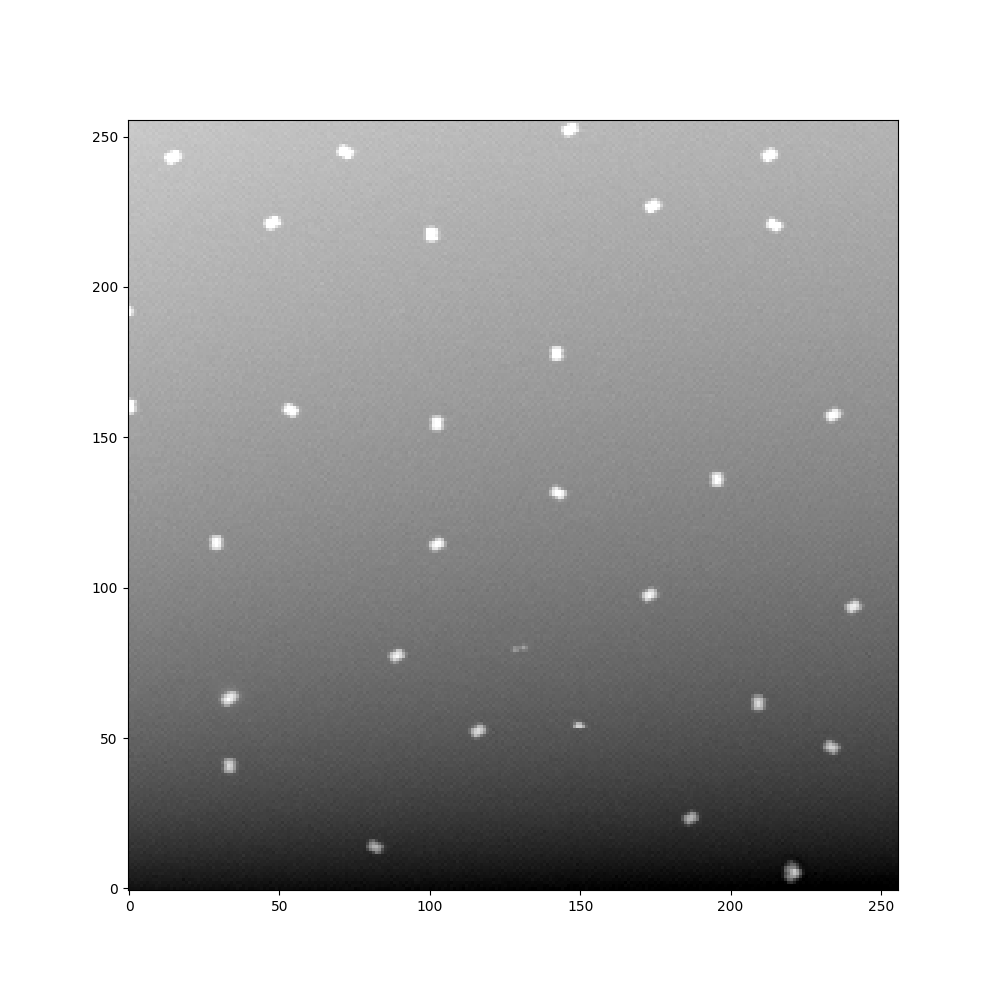

In [45]:
plt.figure()
plt.imshow(ds[12].frames[0][0])
plt.imshow()

/Users/lucnguyen/opt/anaconda3/envs/elmloc/lib/python3.7/site-packages/ipykernel_launcher.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """
/Users/lucnguyen/opt/anaconda3/envs/elmloc/lib/python3.7/site-packages/ipykernel_launcher.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


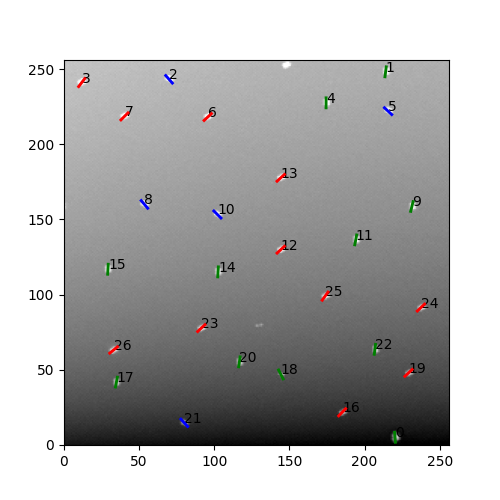

FloatSlider(value=0.0, description='Offset:', max=7.0, step=1.0)

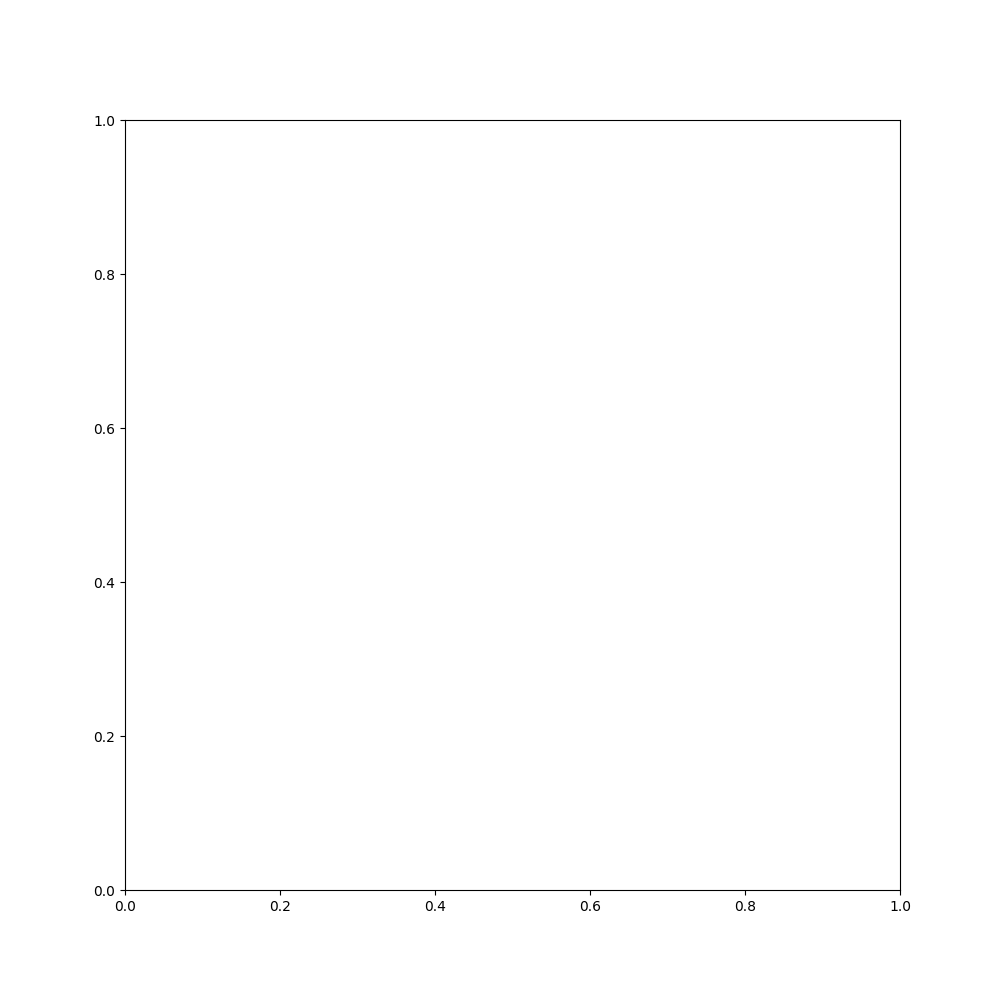

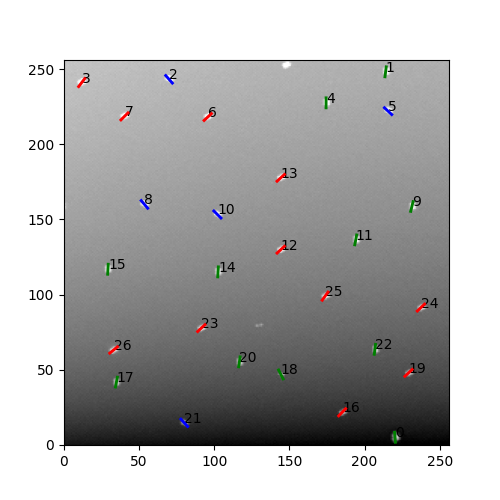

In [59]:
 
def plot_realspace_rot(m,vt_index,frame,theta=0,fig=None,ax=None,xlim=(0,256),ylim=(0,256),grid=True,img=True,angle_adj=0,slider=True):
    df=m.t3s[vt_index].set_index('particle',drop=True)
    ang=(df['orientation']-(np.min(df['orientation'])))%np.pi
    df['conditions']=df['orientation']*0+2
    df['conditions'][(ang>np.pi/6)&(ang<=np.pi*3/6)]=0
    df['conditions'][(ang>np.pi*3/6)&(ang<=np.pi*5/6)]=1
    df_0=df[df['frame']==frame]
    x=df_0['x']
    y=df_0['y']
    center=np.argmin((x-256/2)**2+(y-256/2)**2)
    theta=np.arctan2(y[center-1],x[center-1])+np.pi/3+angle_adj
    lattice = 0.246/m.NM_PER_PIXEL
    if ax==None:
        fig, ax = plt.subplots(figsize=(5,5))
    
    #ax.scatter(df_0.iloc[center]['x'],df_0.iloc[center]['y'])
    colors=['blue','red','green']
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    scatters=[]
    for i in df_0.index:
        plt.annotate(f'{i}',(df_0['x'][i],df_0['y'][i],))
    for i in range(3):
        index=df_0['conditions']==i
        scatters.append((plt.quiver(df_0['x'][index],
                                df_0['y'][index],
                                np.cos((df_0['angle'][index]+np.pi/2)),
                                np.sin((df_0['angle'][index]+np.pi/2)),
                                color=colors[i],
                                scale=30,   
                                zorder=3,
                                headaxislength=0,
                                headlength=0,
                                pivot='mid')))

    if img:
        image=ax.imshow(m.frames[vt_index][frame])
    if grid:
        add_lattice(ax=ax,lattice=lattice,theta=theta,
                          point=(df_0.iloc[center]['x'],df_0.iloc[center]['y']),
                         plotonly=True,size=50)
        print('yeah!')

    if slider:
        def update_plot(change):
            nonlocal scatters
            df_=df[df['frame']==change.new]
            for i in range(3):
                scatters[i].remove()
            for i in range(3):
                index=df_['conditions']==i
                x=df_['x'][index]
                y=df_['y'][index]
                u=np.cos((df_['angle'][index] + np.pi/2))
                v=np.sin((df_['angle'][index] + np.pi/2))
                scatters[i]=((plt.quiver(x,y,u,v,
                                color=colors[i],
                                scale=30,
                                zorder=3,
                                headaxislength=0,
                                headlength=0,
                                pivot='mid')))
            if img:
                image.set_data(m.frames[vt_index][change.new])
            fig.canvas.draw()

        slider = widgets.FloatSlider(
            value=0,
            min=0,
            max=7,
            step=1,
            description='Offset:',
            continuous_update=True)
        #Link the slider to the update function
        slider.observe(update_plot, names='value')
        # Display the plot and the slider
        display(fig.canvas)  # Ensure the figure is displayed
        display(slider)

gate_index=12
ds[gate_index].CorrectDrift(False)
ylim=(0,256)
xlim=(0,256)
vt_index=2
fig,ax=plt.subplots()
test=plot_realspace_rot(ds[gate_index],vt_index,0,theta=0,fig=fig,grid=False,
                        img=True,slider=True,xlim=xlim,ylim=ylim)



In [20]:
1

1

/Users/lucnguyen/opt/anaconda3/envs/elmloc/lib/python3.7/site-packages/ipykernel_launcher.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  import sys
/Users/lucnguyen/opt/anaconda3/envs/elmloc/lib/python3.7/site-packages/ipykernel_launcher.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


./rotation_animation/charged_0
./rotation_animation/charged_1
./rotation_animation/charged_2
./rotation_animation/charged_3
./rotation_animation/charged_4
./rotation_animation/charged_5
./rotation_animation/charged_6
./rotation_animation/charged_7


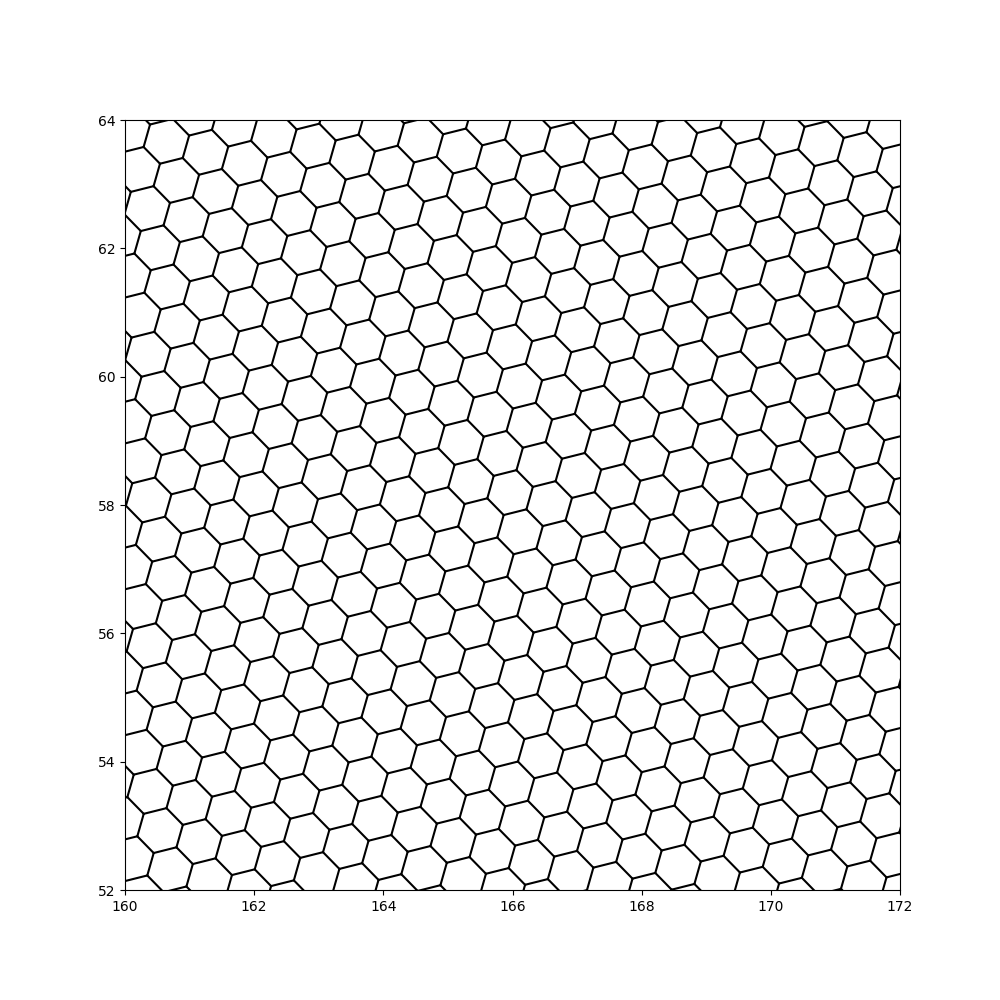

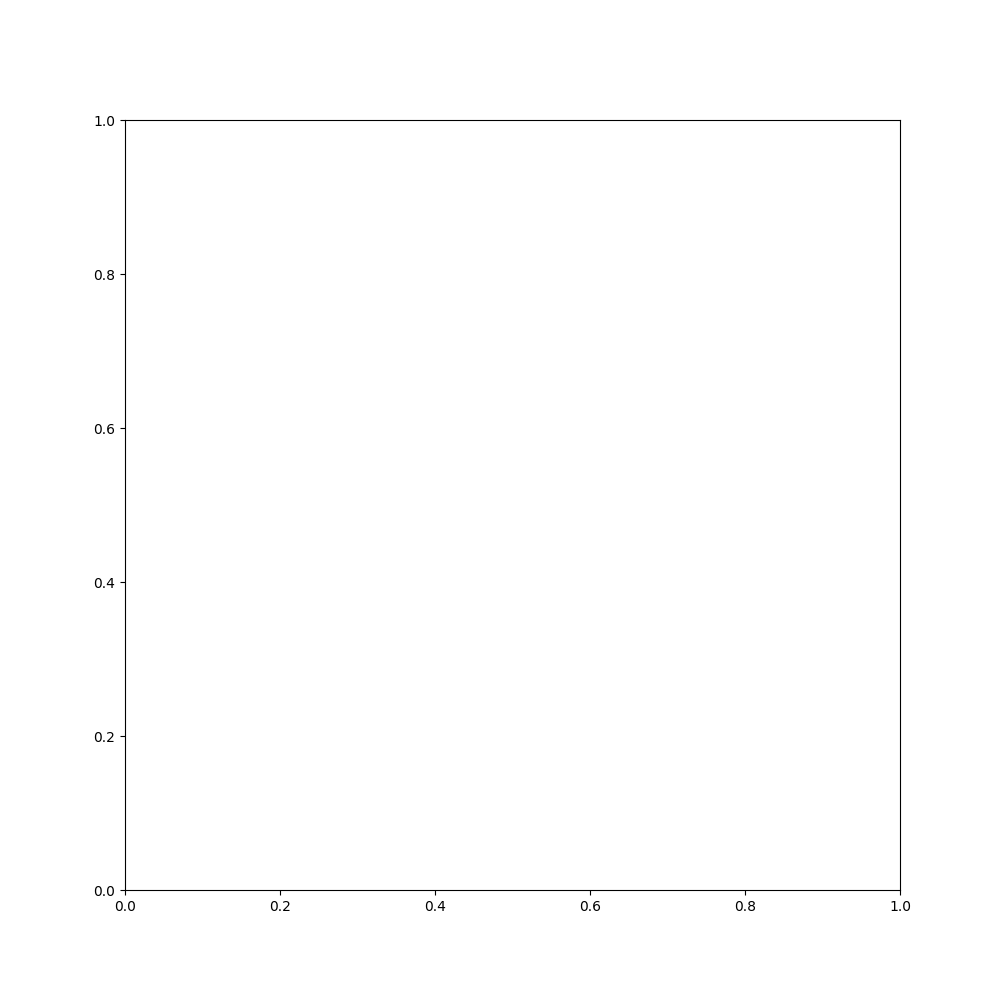

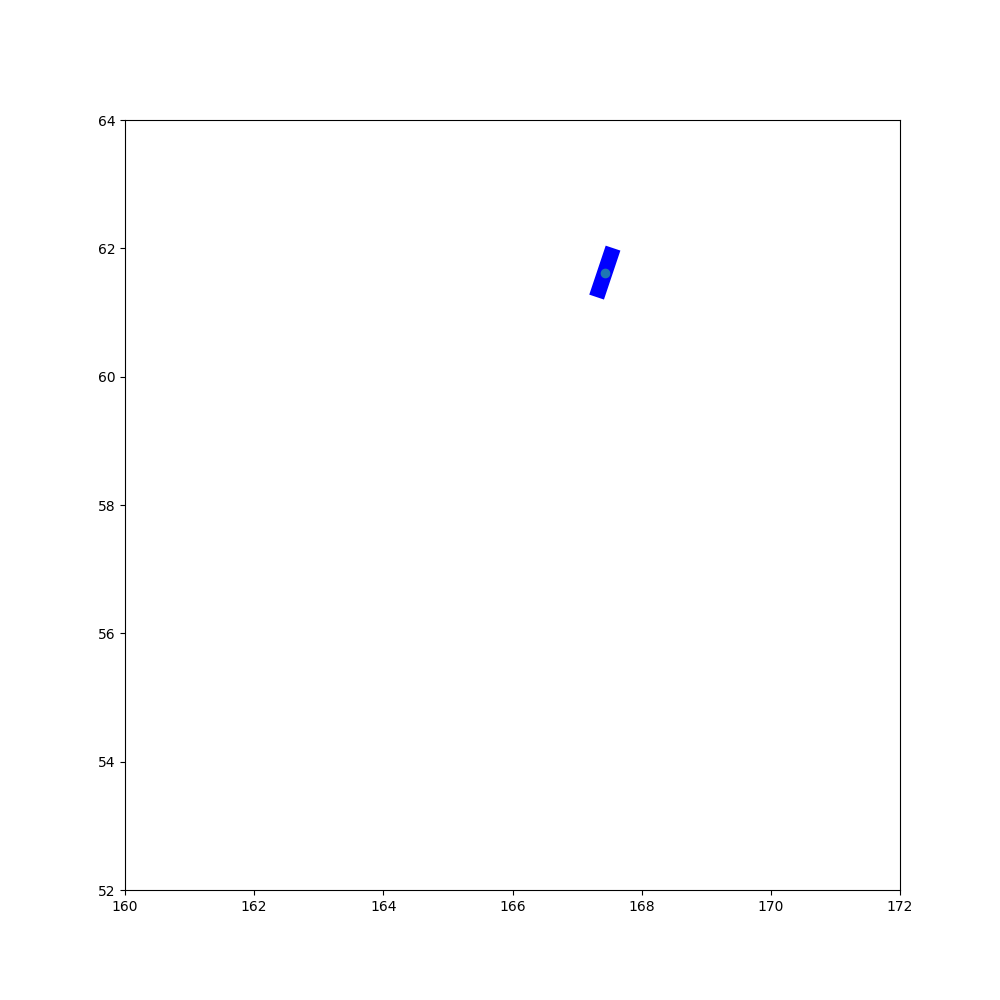

In [58]:
particles=(34,34,34)
size=2.5*np.abs(xlim[1]-xlim[0])
m=ds[gate_index]
df=m.t3s[vt_index].reset_index(drop=True)
ang=(df['orientation']-(np.min(df['orientation'])))%np.pi
df['conditions']=df['orientation']*0+1
df['conditions'][(ang>np.pi/6)&(ang<=np.pi*3/6)]=2
df['conditions'][(ang>np.pi*3/6)&(ang<=np.pi*5/6)]=0
lattice=lattice = 0.246/m.NM_PER_PIXEL
df_particles=df[(df['particle'] == particles[0]) 
                | (df['particle'] == particles[1])
                | (df['particle'] == particles[2])]
df_particles.reset_index(drop=True,inplace=True)
fig,ax=plt.subplots()
#sites=add_lattice(ax=ax,lattice=lattice,theta=0,
 #                         point=(df_particles.iloc[7]['x'],df_particles.iloc[7]['y']),
  #                       plotonly=False,size=size)
#theta_opt=optimal_rotation(sites,
 #                          np.column_stack((df_particles['x'],df_particles['y'])),
  #                         np.array((df_particles.iloc[0]['x'],df_particles.iloc[0]['y'])),
   #                       theta_0=df_particles.iloc[0]['angle']+np.pi/2)
theta_opt=df_particles.iloc[0]['angle']+np.pi/2
#ax.scatter(df_particles['x'],df_particles['y'])
add_lattice(ax=ax,lattice=lattice,theta=theta_opt,
            point=(df_particles.iloc[0]['x'],df_particles.iloc[0]['y']),
            plotonly=True,size=size)
ax.set_xlim(xlim)
ax.set_ylim(ylim)
plt.axis('on')
fig.savefig('./rotation_animation/neutral_grid.png',dpi=300)
fig,ax=plt.subplots()    
fig,ax=plt.subplots()

scatters=[]
colors=['blue','red','green']
#ang=(df_particles['orientation']-(np.min(df_particles['orientation'])))%np.pi
#df_particles['conditions']=df_particles['orientation']*0+2
#df_particles['conditions'][(ang>np.pi/6)&(ang<=np.pi*3/6)]=0
#df_particles['conditions'][(ang>np.pi*3/6)&(ang<=np.pi*5/6)]=1
for i in range(8):
    ax.cla()
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    df_0=df_particles[df_particles['frame']==i]
    for k in range(3):
        index=df_0['conditions']==k
        ax.scatter(df_0['x'][index], df_0['y'][index],zorder=10)
        scatters.append((ax.quiver(df_0['x'][index],
                                df_0['y'][index],
                                np.cos((df_0['angle'][index]+np.pi/2)),
                                np.sin((df_0['angle'][index]+np.pi/2)),
                                color=colors[k],
                                headaxislength=0,
                                headlength=0,
                                width=0.02,
    
                                scale=15,   
                                zorder=3,
                                pivot='mid')))
    #time.sleep(1)
    plt.axis('on')
    fig.savefig(f'./rotation_animation/_a_charged_{i}.svg',transparent=True)
    print(f'./rotation_animation/charged_{i}')

/Users/lucnguyen/opt/anaconda3/envs/elmloc/lib/python3.7/site-packages/ipykernel_launcher.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  
/Users/lucnguyen/opt/anaconda3/envs/elmloc/lib/python3.7/site-packages/ipykernel_launcher.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if __name__ == "__main__":
/Users/lucnguyen/opt/anaconda3/envs/elmloc/lib/python3.7/site-packages/ipykernel_launcher.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pand

./rotation_animation/neutral_0
./rotation_animation/neutral_1
./rotation_animation/neutral_2
./rotation_animation/neutral_3
./rotation_animation/neutral_4
./rotation_animation/neutral_5
./rotation_animation/neutral_6
./rotation_animation/neutral_7


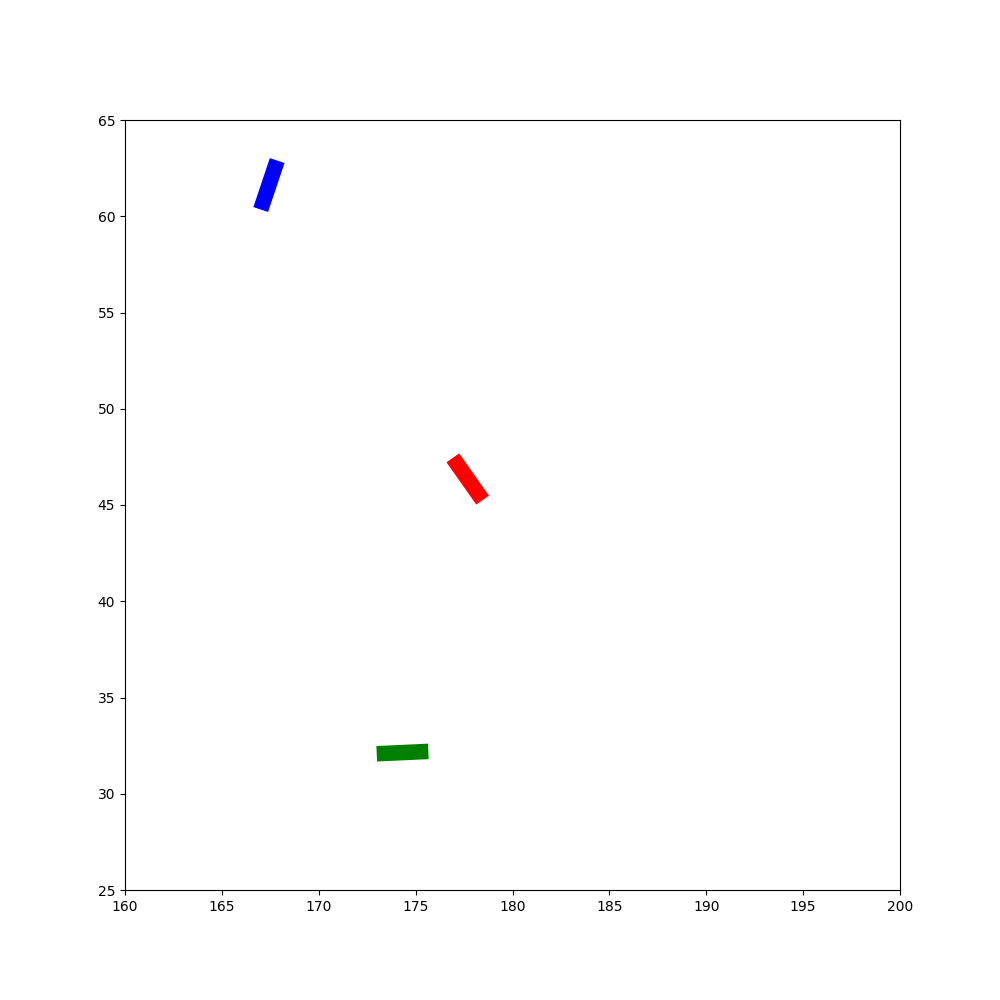

In [109]:
#for i in scatters:
 #   i.remove()
fig,ax=plt.subplots()

scatters=[]
colors=['blue','red','green']
ang=(df_particles['orientation']-(np.min(df_particles['orientation'])))%np.pi
df_particles['conditions']=df_particles['orientation']*0+2
df_particles['conditions'][(ang>np.pi/6)&(ang<=np.pi*3/6)]=0
df_particles['conditions'][(ang>np.pi*3/6)&(ang<=np.pi*5/6)]=1
for i in range(8):
    ax.cla()
    ax.set_xlim(160,200)
    ax.set_ylim(25,65)
    df_0=df_particles[df_particles['frame']==i]
    for k in range(3):
        index=df_0['conditions']==k
        scatters.append((ax.quiver(df_0['x'][index],
                                df_0['y'][index],
                                np.cos((df_0['angle'][index]+np.pi/2)),
                                np.sin((df_0['angle'][index]+np.pi/2)),
                                color=colors[k],
                                headaxislength=0,
                                headlength=0,
                                width=0.02,
    
                                scale=15,   
                                zorder=3,
                                pivot='mid')))
    #time.sleep(1)
    plt.axis('on')
    fig.savefig(f'./rotation_animation/_a_neutral_{i}.svg',transparent=True)
    print(f'./rotation_animation/neutral_{i}')
plt.show()

ERROR:tornado.application:Exception in callback <bound method TimerBase._on_timer of <matplotlib.backends.backend_webagg_core.TimerTornado object at 0x7fbfbcbbf4d0>>
Traceback (most recent call last):
  File "/Users/lucnguyen/opt/anaconda3/envs/elmloc/lib/python3.7/site-packages/tornado/ioloop.py", line 921, in _run
    val = self.callback()
  File "/Users/lucnguyen/opt/anaconda3/envs/elmloc/lib/python3.7/site-packages/matplotlib/backend_bases.py", line 1198, in _on_timer
    ret = func(*args, **kwargs)
  File "/Users/lucnguyen/opt/anaconda3/envs/elmloc/lib/python3.7/site-packages/matplotlib/animation.py", line 1408, in _step
    self._init_draw()
  File "/Users/lucnguyen/opt/anaconda3/envs/elmloc/lib/python3.7/site-packages/matplotlib/animation.py", line 1696, in _init_draw
    self._draw_frame(frame_data)
  File "/Users/lucnguyen/opt/anaconda3/envs/elmloc/lib/python3.7/site-packages/matplotlib/animation.py", line 1718, in _draw_frame
    self._drawn_artists = self._func(framedata, *s

In [106]:

quivers[0]

ValueError: Argument U has a size 16 which does not match 0, the number of arrow positions

In [101]:
colors=['blue','red','green']
quivers = [ax.quiver([], [], color=color, scale=40,
                     headwidth=10, headlength=100, pivot='mid')
           for color in colors]
def animate(i):
    #df_ = df_particles[df_particles['frame'] == i]
    
    for k, quiver in enumerate(quivers):
        index = df_['conditions'] == k
        quiver.set_offsets(np.column_stack((df_['x'][index], df_['y'][index])))
        quiver.set_UVC(np.cos((df_['angle'][index] + np.pi/2)),
                        np.sin((df_['angle'][index] + np.pi/2)))
    
    return quivers

anim = FuncAnimation(fig, animate,frames=3, interval=20, blit=True)
anim.save('scatter_animation.gif', writer='pillow', fps=20)


IndexError: list index out of range

/Users/lucnguyen/opt/anaconda3/envs/elmloc/lib/python3.7/site-packages/ipykernel_launcher.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """
/Users/lucnguyen/opt/anaconda3/envs/elmloc/lib/python3.7/site-packages/ipykernel_launcher.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


FloatSlider(value=0.0, description='Offset:', max=7.0, step=1.0)

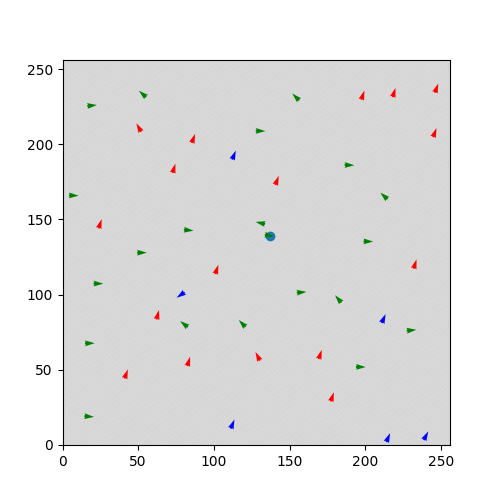

In [15]:
def plot_realspace_rot(m,vt_index,frame,ax=None,xlim=(0,256),ylim=(0,256),grid=True,img=True,angle_adj=0,slider=True):
    df=m.t3s[vt_index].set_index('particle',drop=True)
    ang=(df['orientation']-(np.min(df['orientation'])))%np.pi
    df['conditions']=df['orientation']*0+2
    df['conditions'][(ang>np.pi/6)&(ang<=np.pi*3/6)]=0
    df['conditions'][(ang>np.pi*3/6)&(ang<=np.pi*5/6)]=1
    df_0=df[df['frame']==frame]
    x=df_0['x']
    y=df_0['y']
    center=np.argmin((x-256/2)**2+(y-256/2)**2)
    theta=np.arctan2(y[center-1],x[center-1])+np.pi/3+angle_adj
    lattice = 0.246/m.NM_PER_PIXEL
    if ax==None:
        fig, ax = plt.subplots(figsize=(5,5))
    if grid:
        for j, phi in enumerate(np.linspace(0,4*np.pi/3,3)):
            for i in np.arange(-700,700):
                x_ = np.linspace(-400,400,51)+x[center]
                y_ = (x_-x[center])*np.tan(theta+ phi) + i*lattice/np.cos(theta+ phi)*np.sqrt(3)/2+y[center]
                ax.plot(x_,y_,color='silver', linestyle = '-', linewidth=0.2,zorder=1,alpha=0.8)
    ax.scatter(df_0.iloc[center]['x'],df_0.iloc[center]['y'])
    colors=['blue','red','green']
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    scatters=[]
    for i in range(3):
        index=df_0['conditions']==i
        scatters.append((plt.quiver(df_0['x'][index],
                                df_0['y'][index],
                                np.cos((df_0['angle'][index]+np.pi/2)),
                                np.sin((df_0['angle'][index]+np.pi/2)),
                                color=colors[i],
                                scale=40,
                                zorder=3,
                                pivot='mid')))
    if img:
        image=ax.imshow(m.frames[vt_index][frame])
    if slider:
        def update_plot(change):
            nonlocal scatters

            df_=df[df['frame']==change.new]
            for i in range(3):
                scatters[i].remove()
            for i in range(3):
                index=df_['conditions']==i
                x=df_['x'][index]
                y=df_['y'][index]
                u=np.cos((df_['angle'][index] + np.pi/2))
                v=np.sin((df_['angle'][index] + np.pi/2))
                scatters[i]=((plt.quiver(x,y,u,v,
                                color=colors[i],
                                scale=40,
                                zorder=3,
                                pivot='mid')))
            if img:
                image.set_data(m.frames[vt_index][change.new])
            fig.canvas.draw()

        slider = widgets.FloatSlider(
            value=0,
            min=0,
            max=7,
            step=1,
            description='Offset:',
            continuous_update=True)
        #Link the slider to the update function
        slider.observe(update_plot, names='value')
        # Display the plot and the slider
        #display(fig.canvas)  # Ensure the figure is displayed
        display(slider)
ds[12].CorrectDrift(False)
test=plot_realspace_rot(ds[0],4,1,img=False,slider=True)

In [61]:
10e-13

1e-12

In [66]:
T=140e-9
C=220e-12
1/(4*np.pi/T)/C

50.64020916560307